# Netflix Content Analysis Visualizations

The visualization data used in this notebook was exported from Hive query results generated in Apache Zeppelin. The TSV files stored in `data/hive_outputs/` are based on the cleaned Hive table. Python was then used to generate polished visualizations for better presentation.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("visualizations", exist_ok=True)

content_type_df = pd.read_csv("data/hive_outputs/01_content_type_distribution.tsv", sep="\t")
country_df = pd.read_csv("data/hive_outputs/02_top10_countries.tsv", sep="\t")
rating_df = pd.read_csv("data/hive_outputs/03_rating_distribution.tsv", sep="\t")
release_year_df = pd.read_csv("data/hive_outputs/04_release_year_trend.tsv", sep="\t")
genre_df = pd.read_csv("data/hive_outputs/05_top10_genres.tsv", sep="\t")
duration_df = pd.read_csv("data/hive_outputs/06_movie_duration_group.tsv", sep="\t")

content_type_df

,content_type,total_count
0,Movie,6125
1,TV Show,2664


In [31]:
BG = "#F7F8FA"
TEXT = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
RED = "#E50914"
BLUE = "#2563EB"
TEAL = "#14B8A6"
ORANGE = "#F97316"
PURPLE = "#7C3AED"

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

def clean_axis(ax, grid_axis="x"):
    ax.set_facecolor("white")
    ax.grid(axis=grid_axis, color=GRID, linewidth=1, alpha=0.8)
    ax.tick_params(colors=MUTED)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_visible(False)

def save_fig(fig, filename):
    fig.patch.set_facecolor(BG)
    plt.tight_layout()
    plt.savefig(
        f"visualizations/{filename}",
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()

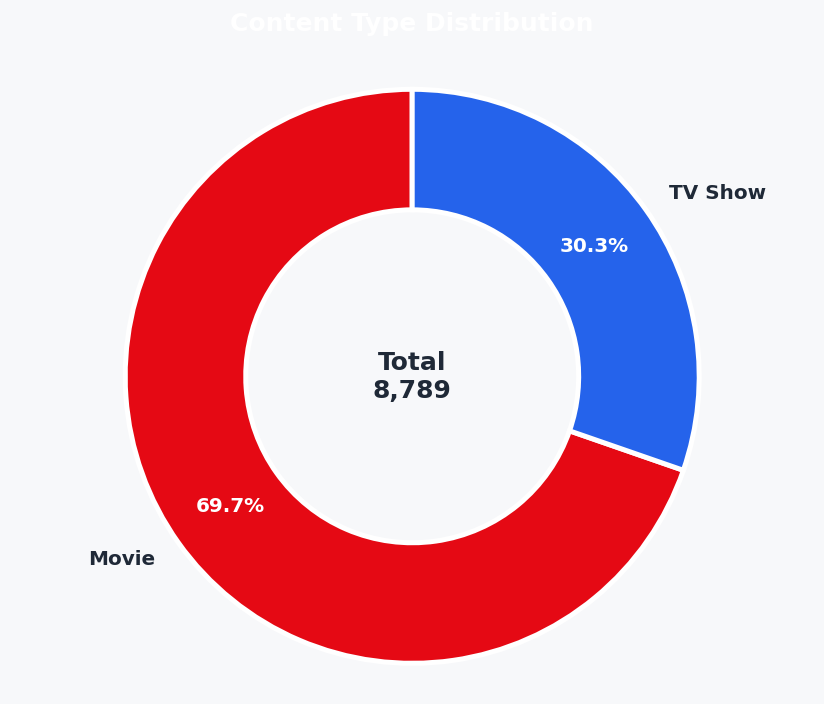

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor("white")

colors = [RED, BLUE]

wedges, texts, autotexts = ax.pie(
    content_type_df["total_count"],
    labels=content_type_df["content_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 3},
    textprops={"fontsize": 12, "color": TEXT, "fontweight": "bold"}
)

for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")

total = content_type_df["total_count"].sum()

ax.text(
    0, 0,
    f"Total\n{total:,}",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=TEXT
)

ax.set_title("Content Type Distribution", fontweight="bold", pad=18)
ax.axis("equal")

save_fig(fig, "01_content_type_distribution.png")

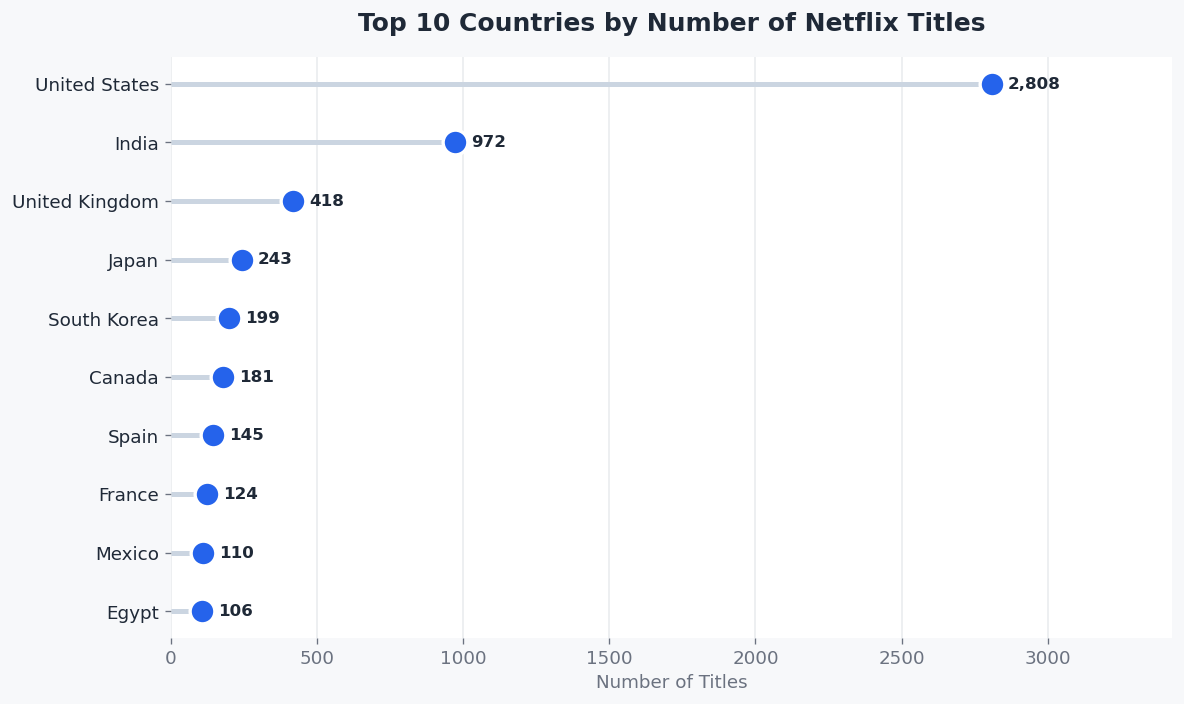

In [35]:
country_plot = country_df.sort_values("total_count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
clean_axis(ax, grid_axis="x")

labels = country_plot["country"]
values = country_plot["total_count"]
y = np.arange(len(labels))

ax.hlines(y=y, xmin=0, xmax=values, color="#CBD5E1", linewidth=3)

ax.scatter(
    values,
    y,
    s=220,
    color=BLUE,
    edgecolor="white",
    linewidth=2,
    zorder=3
)

for i, v in enumerate(values):
    ax.text(
        v + 55,
        i,
        f"{v:,}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11, color=TEXT)
ax.set_xlabel("Number of Titles")
ax.set_title("Top 10 Countries by Number of Netflix Titles", fontweight="bold", pad=16)
ax.set_xlim(0, values.max() * 1.22)

save_fig(fig, "02_top10_countries.png")

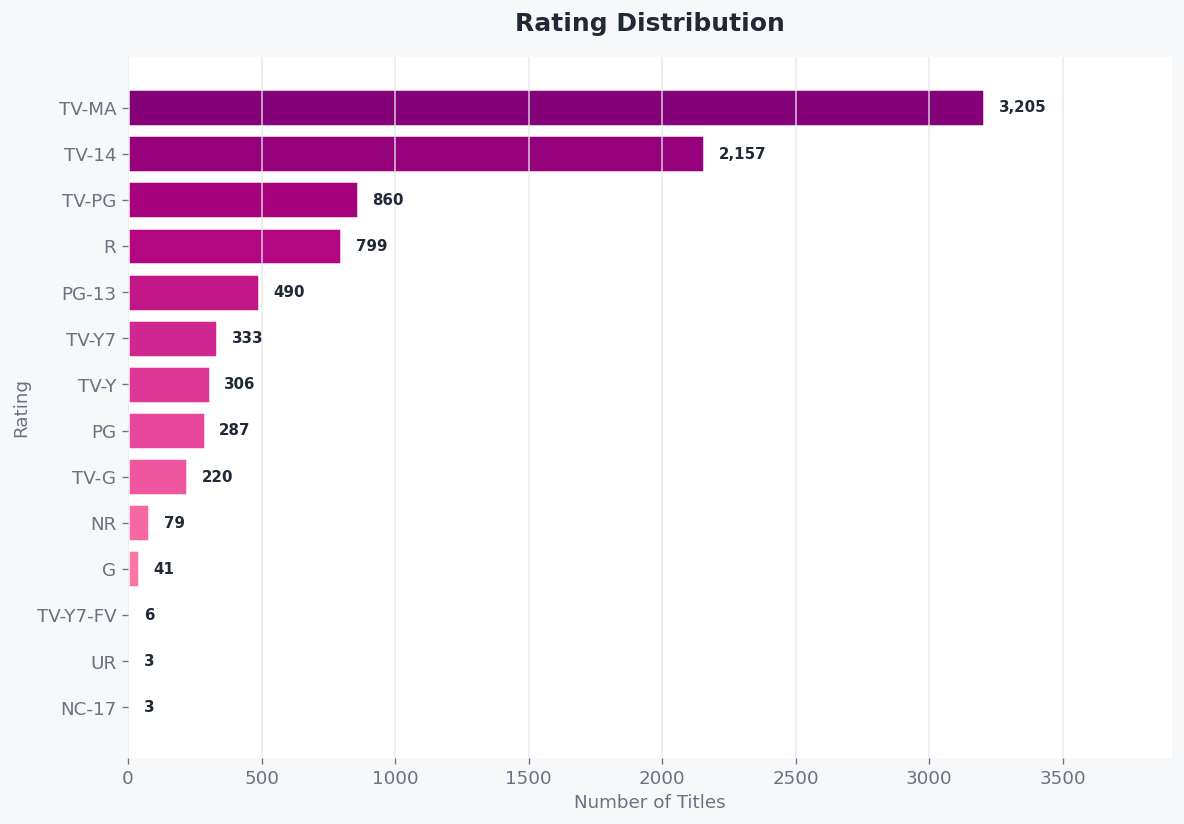

In [37]:
rating_plot = rating_df.sort_values("total_count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
clean_axis(ax, grid_axis="x")

labels = rating_plot["rating"]
values = rating_plot["total_count"]
colors = plt.cm.RdPu(np.linspace(0.35, 0.85, len(labels)))

bars = ax.barh(
    labels,
    values,
    color=colors,
    edgecolor="white",
    linewidth=1.5
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 55,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9,
        color=TEXT,
        fontweight="bold"
    )

ax.set_xlabel("Number of Titles")
ax.set_ylabel("Rating")
ax.set_title("Rating Distribution", fontweight="bold", pad=16)
ax.set_xlim(0, values.max() * 1.22)

save_fig(fig, "03_rating_distribution.png")

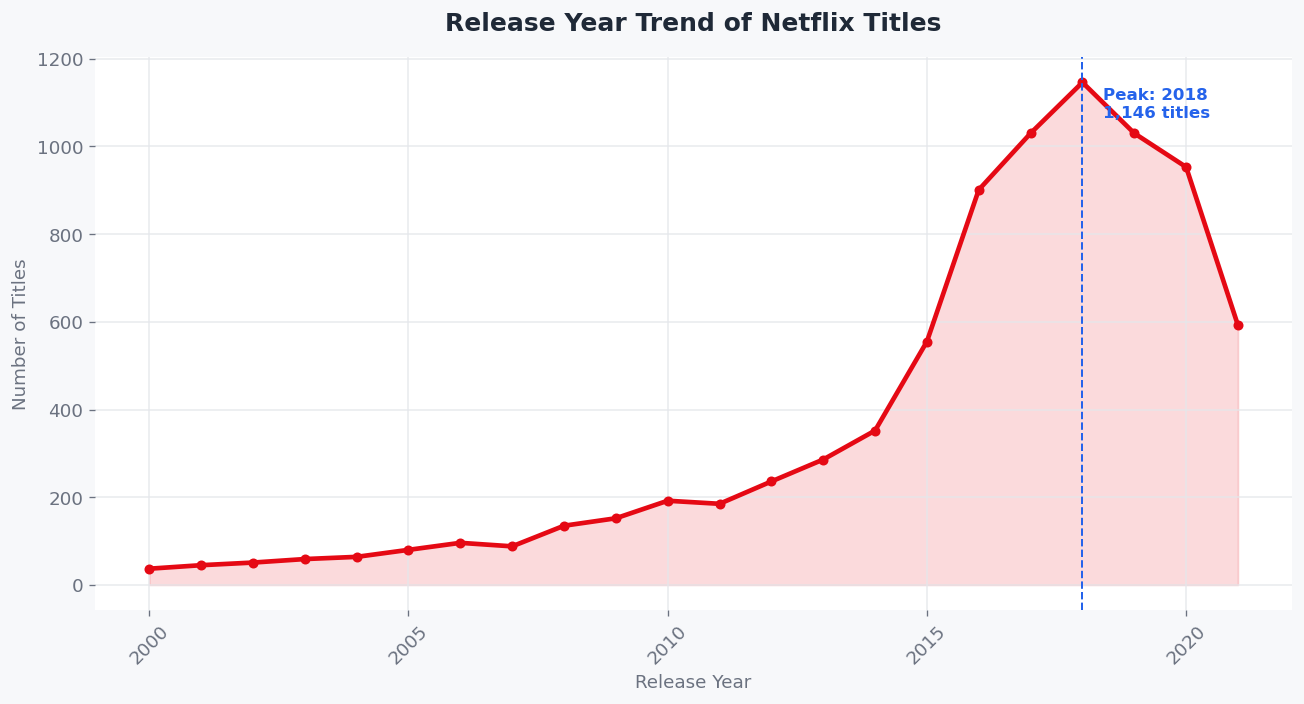

In [39]:
release_year_df["release_year"] = release_year_df["release_year"].astype(int)
release_year_df["total_count"] = release_year_df["total_count"].astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
clean_axis(ax, grid_axis="both")

ax.plot(
    release_year_df["release_year"],
    release_year_df["total_count"],
    color=RED,
    linewidth=2.8,
    marker="o",
    markersize=5
)

ax.fill_between(
    release_year_df["release_year"],
    release_year_df["total_count"],
    color=RED,
    alpha=0.15
)

peak = release_year_df.loc[release_year_df["total_count"].idxmax()]

ax.axvline(
    peak["release_year"],
    color=BLUE,
    linestyle="--",
    linewidth=1.2
)

ax.text(
    peak["release_year"] + 0.4,
    peak["total_count"] - 80,
    f"Peak: {int(peak['release_year'])}\n{int(peak['total_count']):,} titles",
    color=BLUE,
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Release Year Trend of Netflix Titles", fontweight="bold", pad=16)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.tick_params(axis="x", rotation=45)

save_fig(fig, "04_release_year_trend.png")

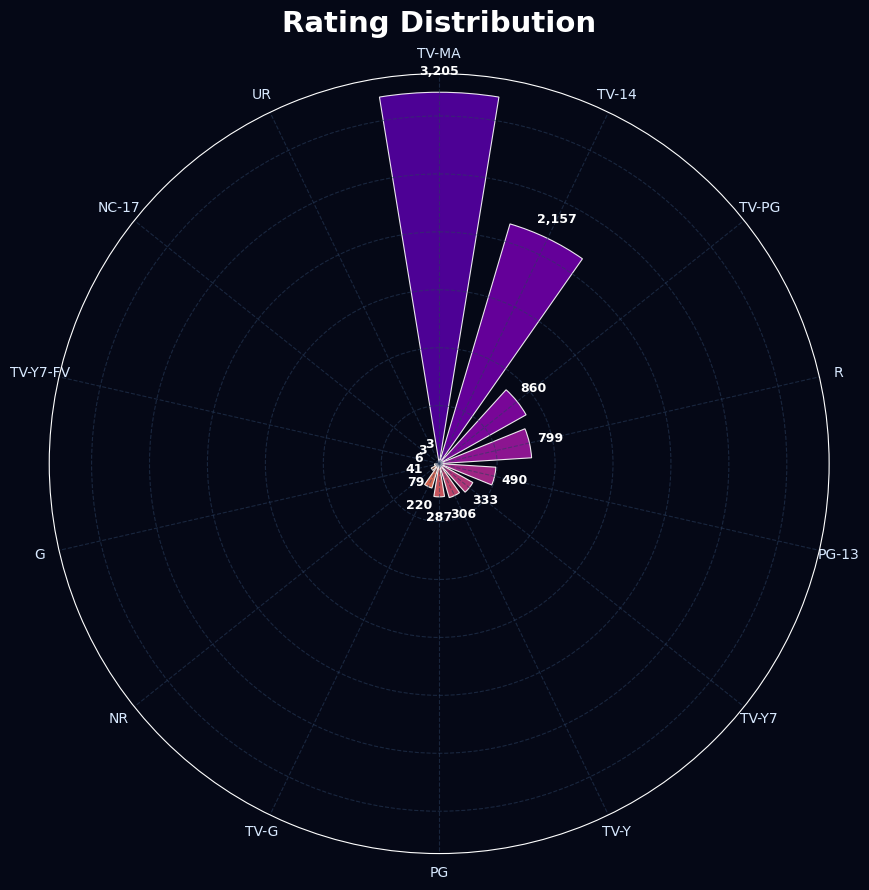

In [23]:
rating_plot = rating_df.sort_values("total_count", ascending=False)

plt.style.use("dark_background")

labels = rating_plot["rating"].tolist()
values = rating_plot["total_count"].astype(int).tolist()

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
width = 2 * np.pi / len(labels) * 0.72

fig = plt.figure(figsize=(9, 9))
fig.patch.set_facecolor("#050816")

ax = plt.subplot(111, polar=True)
ax.set_facecolor("#050816")

colors = plt.cm.plasma(np.linspace(0.15, 0.95, len(labels)))

bars = ax.bar(
    angles,
    values,
    width=width,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.8
)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10, color="#D8E9FF")

ax.set_yticklabels([])
ax.grid(color="#2A3F5F", linestyle="--", linewidth=0.8, alpha=0.55)

for angle, value, label in zip(angles, values, labels):
    ax.text(
        angle,
        value + 180,
        f"{value:,}",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

ax.set_title(
    "Rating Distribution",
    fontsize=21,
    color="white",
    fontweight="bold",
    pad=30
)

plt.tight_layout()
plt.savefig(
    "visualizations/03_rating_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()

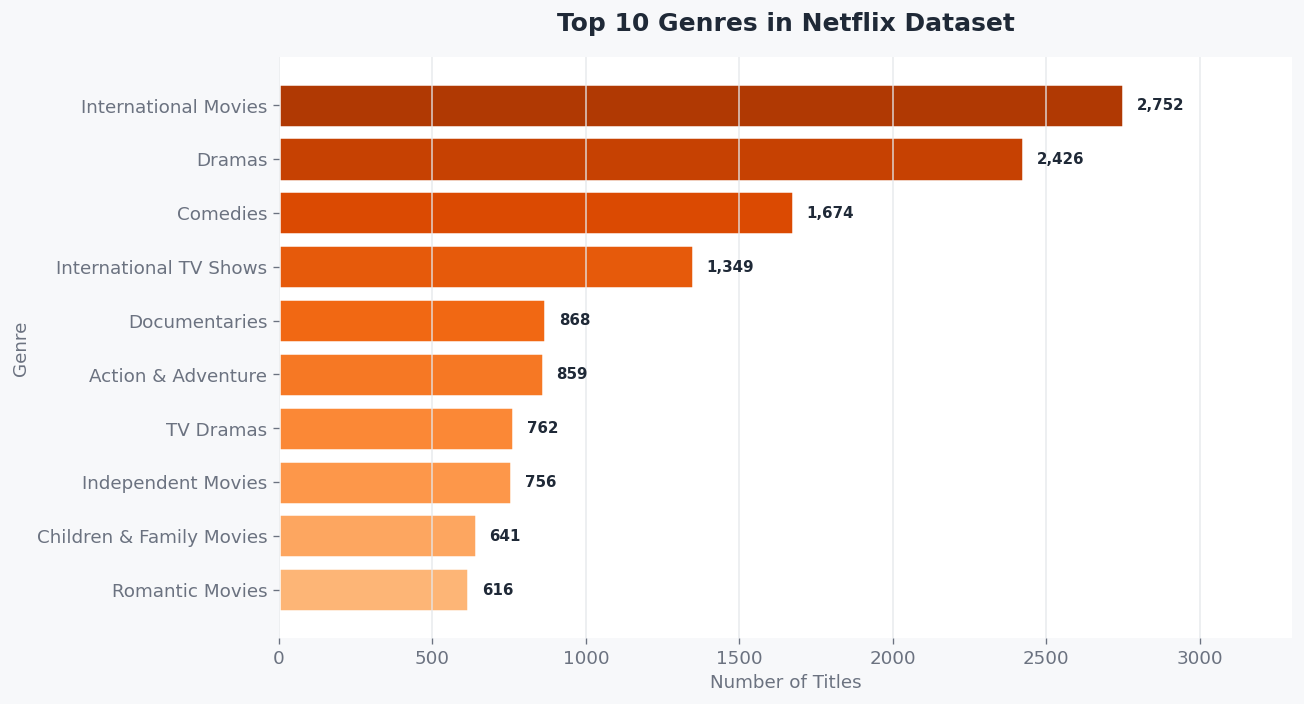

In [41]:
genre_plot = genre_df.sort_values("total_count", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
clean_axis(ax, grid_axis="x")

labels = genre_plot["genre_name"]
values = genre_plot["total_count"]
colors = plt.cm.Oranges(np.linspace(0.35, 0.85, len(labels)))

bars = ax.barh(
    labels,
    values,
    color=colors,
    edgecolor="white",
    linewidth=1.5
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 45,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9,
        color=TEXT,
        fontweight="bold"
    )

ax.set_xlabel("Number of Titles")
ax.set_ylabel("Genre")
ax.set_title("Top 10 Genres in Netflix Dataset", fontweight="bold", pad=16)
ax.set_xlim(0, values.max() * 1.2)

save_fig(fig, "05_top10_genres.png")

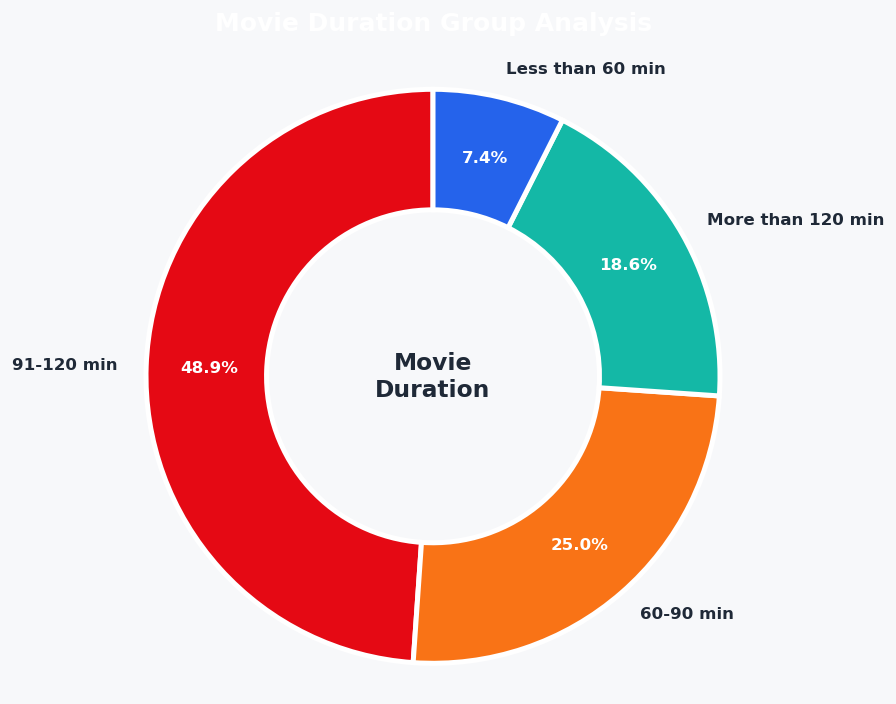

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor("white")

colors = [RED, ORANGE, TEAL, BLUE]

wedges, texts, autotexts = ax.pie(
    duration_df["total_count"],
    labels=duration_df["duration_group"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 3},
    textprops={"fontsize": 10, "color": TEXT, "fontweight": "bold"}
)

for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")

ax.text(
    0, 0,
    "Movie\nDuration",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=TEXT
)

ax.set_title("Movie Duration Group Analysis", fontweight="bold", pad=18)
ax.axis("equal")

save_fig(fig, "06_movie_duration_group.png")

n.